# Coding Evaluation Benchmarks

This notebook evaluates the **coding ability** of the deployed LLM using **HumanEval+** and **MBPP+** benchmarks (pass@1) through [EvalHub](https://github.com/eval-hub/eval-hub). All results are tracked in **MLflow**.

**Architecture:**

    Notebook (EvalHub SDK)
        │
        ▼
    EvalHub Service ──────────► MLflow (tracking)
        │
        ▼
    Coding Eval Adapter Pod
        ├── vLLM (generate code via chat API)
        └── mcp-code-sandbox (execute tests, air-gap safe)

**What we'll do:**
1. Configure endpoints and verify prerequisites (including mcp-code-sandbox)
2. Build & register the coding evaluation adapter
3. Submit coding evaluation (HumanEval+ pass@1, MBPP+ pass@1)
4. Monitor progress and view results in MLflow

**Pattern reference:** [rhoai-lmeval-builder-lab](https://github.com/hyogrin/rhoai-lmeval-builder-lab)

**Prerequisites:**
- EvalHub service deployed in `demo` namespace
- Model deployed and accessible via MaaS
- **mcp-code-sandbox** deployed in `mcp-servers` namespace (air-gap safe code execution)
- EvalHub SA (`demo:evalhub-service`) must have permission to create ConfigMaps/Pods in the `demo` namespace

## Step 1: Configuration

In [1]:
import os, sys, time, subprocess

from importlib.metadata import version as pkg_version
print(f"eval-hub-sdk: {pkg_version('eval-hub-sdk')}")
print(f"mlflow:       {pkg_version('mlflow')}")

eval-hub-sdk: 0.1.8
mlflow:       3.13.0


In [2]:
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env")

cluster_domain = subprocess.run(
    ["oc", "get", "ingresses.config", "cluster", "-o", "jsonpath={.spec.domain}"],
    capture_output=True, text=True
).stdout.strip()

NAMESPACE = os.getenv("MODEL_NAMESPACE", "demo")
MODEL_NAME = os.getenv("MODEL_NAME", "qwen36-27b")

EVALHUB_URL = f"https://evalhub-{NAMESPACE}.{cluster_domain}"
AUTH_TOKEN = subprocess.run(["oc", "whoami", "-t"], capture_output=True, text=True).stdout.strip()

# Adapter pods run inside the cluster — use in-cluster kserve workload service URL
MODEL_URL = f"https://{MODEL_NAME}-kserve-workload-svc.{NAMESPACE}.svc.cluster.local:8000/v1"

print(f"Namespace:  {NAMESPACE}")
print(f"EvalHub:    {EVALHUB_URL}")
print(f"Model:      {MODEL_NAME}")
print(f"Model URL:  {MODEL_URL} (in-cluster, used by adapter pods)")

Namespace:  demo
EvalHub:    https://evalhub-demo.apps.openshift-cluster.sandbox1785.opentlc.com
Model:      qwen36-27b
Model URL:  https://qwen36-27b-kserve-workload-svc.demo.svc.cluster.local:8000/v1 (in-cluster, used by adapter pods)


### Verify Prerequisites: RBAC & Connectivity

In [3]:
import urllib.request, ssl, json as _json

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# EvalHub API health check
evalhub_health_url = f"{EVALHUB_URL}/api/v1/health"
try:
    req = urllib.request.Request(evalhub_health_url, headers={"Authorization": f"Bearer {AUTH_TOKEN}"})
    resp = urllib.request.urlopen(req, context=ctx, timeout=10)
    data = _json.loads(resp.read())
    print(f"  [OK] EvalHub health ({data.get('status', resp.status)}) — build {data.get('build', '?')}")
except Exception as e:
    print(f"  [FAIL] EvalHub health: {e}")

# Model reachability (via MaaS gateway, from laptop)
model_ep = os.getenv("MODEL_ENDPOINT", f"https://maas-api.{cluster_domain}/{NAMESPACE}/{MODEL_NAME}")
maas_key = os.getenv("MAAS_API_KEY", "")
test_url = f"{model_ep}/v1/models"
try:
    req = urllib.request.Request(test_url, headers={"Authorization": f"Bearer {maas_key}"})
    resp = urllib.request.urlopen(req, context=ctx, timeout=10)
    models = _json.loads(resp.read()).get("data", [])
    print(f"  [OK] Model reachable via MaaS — {[m['id'] for m in models]}")
except Exception as e:
    print(f"  [WARN] Model MaaS check: {e} (adapter pods use in-cluster URL)")

# mcp-code-sandbox health check (required for coding benchmarks)
sandbox_check = subprocess.run(
    ["oc", "get", "pod", "-n", "mcp-servers", "-l", "app=mcp-code-sandbox",
     "-o", "jsonpath={.items[0].status.phase}"],
    capture_output=True, text=True
)
sandbox_ready = sandbox_check.stdout.strip() == "Running"
print(f"  [{'OK' if sandbox_ready else 'FAIL'}] mcp-code-sandbox pod ({'Running' if sandbox_ready else sandbox_check.stdout.strip() or 'not found'})")

if not sandbox_ready:
    print("    → Deploy mcp-code-sandbox first (see 1_mcp_servers/2_deploy_mcp_servers.ipynb)")

# Check EvalHub SA RBAC
rbac_check = subprocess.run(
    ["oc", "auth", "can-i", "create", "configmaps", "-n", NAMESPACE,
     "--as=system:serviceaccount:demo:evalhub-service"],
    capture_output=True, text=True
)
can_create = rbac_check.stdout.strip() == "yes"
print(f"  [{'OK' if can_create else 'FAIL'}] EvalHub SA can create configmaps in {NAMESPACE}")

if not can_create:
    print(f"\n  Fix with: oc create rolebinding evalhub-manager -n {NAMESPACE} ")
    print(f"    --clusterrole=admin --serviceaccount=demo:evalhub-service")

  [OK] EvalHub health (healthy) — build 0.3.0
  [OK] Model reachable via MaaS — ['qwen36-27b']
  [OK] mcp-code-sandbox pod (Running)
  [OK] EvalHub SA can create configmaps in demo


## Step 2: Initialize EvalHub Client

In [4]:
from evalhub import (
    SyncEvalHubClient,
    ModelConfig,
    BenchmarkConfig,
    JobSubmissionRequest,
    ExperimentConfig,
    ExperimentTag,
    JobStatus,
)

client = SyncEvalHubClient(
    base_url=EVALHUB_URL,
    auth_token=AUTH_TOKEN,
    insecure=True,
    tenant=NAMESPACE,
)

model = ModelConfig(
    url=MODEL_URL,
    name=MODEL_NAME,
)

print(f"EvalHub client connected: {EVALHUB_URL}")
print(f"Model target: {model.name} @ {model.url}")

TLS verification disabled - skipping CA bundle detection
TLS verification disabled (insecure mode)


EvalHub client connected: https://evalhub-demo.apps.openshift-cluster.sandbox1785.opentlc.com
Model target: qwen36-27b @ https://qwen36-27b-kserve-workload-svc.demo.svc.cluster.local:8000/v1


## Step 3: Verify Providers

In [5]:
providers = client.providers.list()
print(f"Registered providers: {len(providers)}")
for p in providers:
    print(f"  - {p.name} (id={p.resource.id})")
    for bm in p.benchmarks:
        print(f"      {bm.id}: {bm.name}")

Registered providers: 6
  - LM Evaluation Harness (id=lm_evaluation_harness)
      arc_easy: Basic science Q&A
      AraDiCE_boolq_lev: Yes/no question answering (Levantine Arabic)
      blimp: Grammar & syntax judgment
      blimp_anaphor_gender_agreement: Pronoun gender matching
      blimp_animate_subject_trans: Animacy constraints on verbs
      blimp_coordinate_structure_constraint_complex_left_branch: Complex sentence structure
      blimp_determiner_noun_agreement_2: Determiner-noun number agreement
      blimp_determiner_noun_agreement_with_adj_2: Agreement across adjectives (variant 2)
      blimp_determiner_noun_agreement_with_adjective_1: Agreement across adjectives (variant 1)
      blimp_existential_there_object_raising: Existential construction (object)
      blimp_existential_there_subject_raising: Existential construction (subject)
      blimp_intransitive: Verb argument structure
      blimp_irregular_plural_subject_verb_agreement_1: Irregular plural agreement
      bl

### Build & Register Coding Eval Adapter

Build the coding-eval adapter image (HumanEval+ / MBPP+ evaluator) and register it with EvalHub.
The adapter generates code via vLLM and executes test suites in **mcp-code-sandbox** — no `HF_ALLOW_CODE_EVAL` needed, air-gap safe.

In [6]:
import yaml

ADAPTER_DIR = "adapters/coding-eval"

# --- Build the adapter image via OpenShift BuildConfig ---
print("Creating BuildConfig for coding-eval-adapter...")
bc_result = subprocess.run(
    ["oc", "new-build", "--strategy=docker",
     "--name=coding-eval-adapter", "--binary=true", "-n", NAMESPACE],
    capture_output=True, text=True,
)
if bc_result.returncode == 0:
    print("  BuildConfig created")
    # Our adapter uses Containerfile (not Dockerfile)
    subprocess.run(
        ["oc", "patch", "bc/coding-eval-adapter", "-n", NAMESPACE,
         "-p", '{"spec":{"strategy":{"dockerStrategy":{"dockerfilePath":"Containerfile"}}}}'],
        capture_output=True, text=True,
    )
elif "already exists" in bc_result.stderr:
    print("  BuildConfig already exists")
else:
    print(f"  WARNING: {bc_result.stderr.strip()[:200]}")

print(f"\nBuilding image from {ADAPTER_DIR}/ (this takes 2-3 minutes)...")
build_result = subprocess.run(
    ["oc", "start-build", "coding-eval-adapter",
     f"--from-dir={ADAPTER_DIR}", "-n", NAMESPACE, "--follow"],
    capture_output=True, text=True, timeout=600,
)
if build_result.returncode == 0:
    print("  Image built successfully!")
else:
    last_lines = "\n".join(build_result.stdout.strip().split("\n")[-5:])
    print(f"  Build output:\n{last_lines}")
    if build_result.returncode != 0:
        raise RuntimeError(f"Adapter image build failed (exit {build_result.returncode})")

# --- Register the coding-eval provider with EvalHub ---
import httpx

CODING_PROVIDER_NAME = "Coding Evaluation"

# Check if already registered
CODING_PROVIDER_ID = None
for p in client.providers.list():
    if p.name == CODING_PROVIDER_NAME:
        CODING_PROVIDER_ID = p.resource.id
        print(f"Coding eval provider already registered (id={CODING_PROVIDER_ID})")
        break

if CODING_PROVIDER_ID is None:
    raw = open(f"{ADAPTER_DIR}/provider.yaml").read().replace("${NAMESPACE}", NAMESPACE)
    provider_def = yaml.safe_load(raw)

    resp = httpx.post(
        f"{EVALHUB_URL}/api/v1/evaluations/providers",
        headers={
            "Authorization": f"Bearer {AUTH_TOKEN}",
            "Content-Type": "application/json",
            "X-Tenant": NAMESPACE,
        },
        json=provider_def,
        verify=False,
        timeout=10,
    )
    if resp.status_code in (200, 201):
        data = resp.json()
        CODING_PROVIDER_ID = data["resource"]["id"]
        n = len(data.get("benchmarks") or [])
        print(f"Coding eval provider registered (id={CODING_PROVIDER_ID}, {n} benchmarks)")
    else:
        raise RuntimeError(f"Provider registration failed ({resp.status_code}): {resp.text[:300]}")

# Verify
for p in client.providers.list():
    if p.resource.id == CODING_PROVIDER_ID:
        print(f"\n  Name: {p.name}")
        print(f"  ID:   {CODING_PROVIDER_ID}")
        print(f"  Benchmarks:")
        for bm in p.benchmarks:
            print(f"    - {bm.id:20s} {bm.name}")
        break

Creating BuildConfig for coding-eval-adapter...
  BuildConfig already exists

Building image from adapters/coding-eval/ (this takes 2-3 minutes)...
  Image built successfully!
Coding eval provider already registered (id=c16eacca-1eca-4c6d-b00d-3ab2cf272443)

  Name: Coding Evaluation
  ID:   c16eacca-1eca-4c6d-b00d-3ab2cf272443
  Benchmarks:
    - humaneval_plus       HumanEval+
    - mbpp_plus            MBPP+


## Step 4: Helper — Monitor Job Progress

In [7]:
TERMINAL_STATES = {
    JobStatus.COMPLETED,
    JobStatus.FAILED,
    JobStatus.CANCELLED,
    JobStatus.PARTIALLY_FAILED,
}


def wait_for_job(client, job_id, poll_interval=10, max_wait=600):
    """Poll job status until terminal state or timeout."""
    start = time.time()
    print(f"Monitoring job {job_id}...")
    print("-" * 70)

    while time.time() - start < max_wait:
        status = client.jobs.get(job_id)
        state = status.effective_state
        elapsed = int(time.time() - start)

        msg = ""
        if status.status and status.status.message:
            msg = f" | {status.status.message.message}"

        bm_info = ""
        if status.status and status.status.benchmarks:
            bm_states = [f"{b.id}={b.state.value}" for b in status.status.benchmarks]
            bm_info = f" | {', '.join(bm_states)}"

        print(f"  [{elapsed:>4d}s] {state.value:>16s}{msg}{bm_info}")

        if state in TERMINAL_STATES:
            break

        time.sleep(poll_interval)

    print("-" * 70)
    print(f"Final state: {state.value} (elapsed: {elapsed}s)")
    return status


def display_results(job):
    """Display evaluation results with MLflow links."""
    if not job.results:
        print("No results available.")
        if job.status and job.status.message:
            print(f"  Message: {job.status.message.message}")
        return

    print("=" * 70)
    print("  BENCHMARK RESULTS")
    print("=" * 70)

    if job.results.mlflow_experiment_url:
        print(f"\n  MLflow Experiment: {job.results.mlflow_experiment_url}")

    for bm in job.results.benchmarks:
        print(f"\n  Benchmark: {bm.id}")
        print(f"  Provider:  {bm.provider_id}")
        if bm.mlflow_run_id:
            print(f"  MLflow Run: {bm.mlflow_run_id}")

        if bm.metrics:
            print(f"  Metrics:")
            for name, value in bm.metrics.items():
                if isinstance(value, float):
                    print(f"    {name:35s} = {value:.4f}")
                else:
                    print(f"    {name:35s} = {value}")
    print("\n" + "=" * 70)

---

## Coding Evaluation — HumanEval+ & MBPP+

Submit coding benchmarks under one MLflow experiment:

| Benchmark | What it measures | Problems |
|-----------|-----------------|----------|
| `humaneval_plus` | Function completion — pass@1 | 164 |
| `mbpp_plus` | Problem solving — pass@1 | 399 |

The adapter generates code via vLLM and executes test suites in **mcp-code-sandbox** (air-gap safe, no `HF_ALLOW_CODE_EVAL` needed).
Each problem has a per-task timeout — if LLM or sandbox hangs, that problem is marked as failed and evaluation continues.
Full evaluation completes in ~5 minutes.

In [8]:
from datetime import datetime
RUN_TAG = datetime.now().strftime('%m%d-%H%M')
EXPERIMENT_NAME = f"coding-assistant-eval/{MODEL_NAME}"

coding_request = JobSubmissionRequest(
    name=f"coding-eval-{MODEL_NAME}-{RUN_TAG}",
    description=f"Coding evaluation: HumanEval+ + MBPP+ for {MODEL_NAME}",
    tags=["coding", "humaneval", "mbpp"],
    model=model,
    benchmarks=[
        BenchmarkConfig(
            id="humaneval_plus",
            provider_id=CODING_PROVIDER_ID,
            parameters={
                "concurrency": 10,
                "temperature": 0.0,
                "max_tokens": 1024,
                "sandbox_timeout": 15,
            },
        ),
        BenchmarkConfig(
            id="mbpp_plus",
            provider_id=CODING_PROVIDER_ID,
            parameters={
                "concurrency": 10,
                "temperature": 0.0,
                "max_tokens": 1024,
                "sandbox_timeout": 15,
            },
        ),
    ],
    experiment=ExperimentConfig(
        name=EXPERIMENT_NAME,
        tags=[
            ExperimentTag(key="model_family", value="qwen3.6"),
            ExperimentTag(key="evaluation_type", value="coding"),
            ExperimentTag(key="deployment", value="rhoai-maas"),
        ],
    ),
)

coding_job = client.jobs.submit(coding_request)

print(f"Coding evaluation submitted!")
print(f"  Job ID:     {coding_job.id}")
print(f"  Name:       {coding_job.name}")
print(f"  Benchmarks: humaneval_plus (164), mbpp_plus (399)")
print(f"  State:      {coding_job.state.value}")

Coding evaluation submitted!
  Job ID:     041b0568-7e77-4d25-939a-06ddcb491ad5
  Name:       coding-eval-qwen36-27b-0621-1506
  Benchmarks: humaneval_plus (164), mbpp_plus (399)
  State:      pending


In [9]:
completed_coding = wait_for_job(client, coding_job.id, poll_interval=15, max_wait=600)
display_results(completed_coding)

Monitoring job 041b0568-7e77-4d25-939a-06ddcb491ad5...
----------------------------------------------------------------------
  [   0s]          pending | Evaluation job created
  [  15s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [  31s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [  47s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [  63s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [  79s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [  94s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [ 110s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [ 126s]          running | Evaluation job is running | mbpp_plus=running, humaneval_plus=running
  [ 141s]          running | E



## Step 5: Compare Results

In [10]:
jobs_resp = client.jobs.list()
items = jobs_resp.items if hasattr(jobs_resp, 'items') else jobs_resp

print(f"Total Jobs: {len(items)}")
print("=" * 90)
print(f"{'State':>16s}  {'Job ID':12s}  {'Name':35s}  Benchmarks")
print("-" * 90)
for j in items:
    state = j.effective_state.value
    bms = [b.id for b in j.benchmarks] if j.benchmarks else []
    print(f"{state:>16s}  {j.id[:12]:12s}  {j.name[:35]:35s}  {bms}")

Connection error to https://evalhub-demo.apps.openshift-cluster.sandbox1785.opentlc.com/api/v1/evaluations/jobs, retrying in 0.52s (1/3): Server disconnected without sending a response.


Total Jobs: 4
           State  Job ID        Name                                 Benchmarks
------------------------------------------------------------------------------------------
       completed  d5379bab-d82  coding-eval-qwen36-27b-0621-0015     ['humaneval_plus', 'mbpp_plus']
       completed  bdbeff8c-5cc  coding-eval-qwen36-27b-0621-0027     ['humaneval_plus', 'mbpp_plus']
       completed  0b77de38-56c  coding-eval-qwen36-27b-0621-0058     ['humaneval_plus', 'mbpp_plus']
       completed  041b0568-7e7  coding-eval-qwen36-27b-0621-1506     ['humaneval_plus', 'mbpp_plus']


In [11]:
def collect_coding_metrics(client):
    """Collect coding benchmark metrics from completed jobs."""
    jobs_list = client.jobs.list()
    items = jobs_list.items if hasattr(jobs_list, 'items') else jobs_list
    completed = [j for j in items if j.effective_state == JobStatus.COMPLETED]

    rows = []
    for j in completed:
        if not j.results:
            continue
        for bm in j.results.benchmarks:
            if bm.metrics and bm.id in ('humaneval_plus', 'mbpp_plus'):
                row = {"job": j.name, "benchmark": bm.id}
                row.update(bm.metrics)
                if bm.mlflow_run_id:
                    row["mlflow_run_id"] = bm.mlflow_run_id
                rows.append(row)
    return rows


rows = collect_coding_metrics(client)

if rows:
    try:
        import pandas as pd
        df = pd.DataFrame(rows)
        key_cols = [c for c in ['humaneval_plus_pass1', 'mbpp_plus_pass1', 'mlflow_run_id'] if c in df.columns]
        display(df[['job', 'benchmark'] + key_cols].style.format(
            {m: '{:.1f}' for m in key_cols if m in df.columns and df[m].dtype == 'float64'}
        ))
    except ImportError:
        for row in rows:
            print(f"  {row['job']:35s} | {row['benchmark']:15s} | {row}")
else:
    print("No completed coding evaluation jobs yet.")

,job,benchmark,humaneval_plus_pass1,mbpp_plus_pass1,mlflow_run_id
0,coding-eval-qwen36-27b-0621-0015,mbpp_plus,nan,0.0,ba69603d717b4b8c8de479cd1e16f87c
1,coding-eval-qwen36-27b-0621-0015,humaneval_plus,0.0,nan,a500e9f3c43044a4b16c02cb1f5b0cf5
2,coding-eval-qwen36-27b-0621-0027,mbpp_plus,nan,0.0,85ec8e8ab7594ed793277b4553d2a03e
3,coding-eval-qwen36-27b-0621-0027,humaneval_plus,0.0,nan,182c1ce3ad874c26a7a987ef042f5eb3
4,coding-eval-qwen36-27b-0621-0058,humaneval_plus,51.2,nan,a1d0517c88a34bd499092d58115150ac
5,coding-eval-qwen36-27b-0621-0058,mbpp_plus,nan,95.5,332b703786cb40d2a110d87260afbc1a
6,coding-eval-qwen36-27b-0621-1506,mbpp_plus,nan,91.8,fab3058ea27a480da6054dc83e385073
7,coding-eval-qwen36-27b-0621-1506,humaneval_plus,52.4,nan,8e8e4b624a3747b78ad943a15627294c


---

## Step 6: MLflow Integration

![Coding_Assistant](../images/coding_assistant_eval.png)

![MBPP DETAIL](../images/mbpp_eval_detail.png)

Access evaluation results directly from MLflow for advanced analysis, comparison, and visualization.
EvalHub automatically tracks all benchmark results to MLflow.

In [12]:
import mlflow
from mlflow.tracking.request_header.registry import _request_header_provider_registry

# RHOAI MLflow requires X-MLflow-Workspace header for multi-tenant access
class WorkspaceHeaderProvider:
    def in_context(self):
        return True
    def request_headers(self):
        return {'X-MLflow-Workspace': NAMESPACE}

_request_header_provider_registry.register(WorkspaceHeaderProvider)

MLFLOW_TRACKING_URI = f"https://mlflow-external-redhat-ods-applications.{cluster_domain}"
os.environ['MLFLOW_TRACKING_INSECURE_TLS'] = 'true'
os.environ['MLFLOW_TRACKING_TOKEN'] = AUTH_TOKEN
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Workspace:           {NAMESPACE}")
print(f"mlflow version:      {mlflow.__version__}")

MLflow tracking URI: https://mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com
Workspace:           demo
mlflow version:      3.13.0


In [13]:
# List MLflow experiments
experiments = mlflow.search_experiments()

print(f"MLflow Experiments ({len(experiments)}):")
print("=" * 70)
for exp in experiments:
    marker = "  <<<" if "coding" in exp.name.lower() else ""
    print(f"  [{exp.experiment_id:>3s}] {exp.name}{marker}")

/Users/hyochoi/dev/rhoai-coding-assistant-lab/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


MLflow Experiments (41):
  [ 66] coding-assistant-eval/qwen36-27b  <<<
  [ 65] coding-assistant-unified/qwen36-27b  <<<
  [ 64] qwen36-27b-full-eval-0617-1428
  [ 63] gemma4-12b-guidellm-0611-1320
  [ 62] gemma4-12b-full-eval-0611-0959
  [ 61] gemma4-12b-full-eval-0611-0946
  [ 35] coding-assistant-perf/qwen25-coder-7b  <<<
  [ 34] ko-mcq-kobest_boolq-2000-0529-1232
  [ 33] ko-mcq-kmmlu_hard-2000-0529-1232
  [ 32] ko-mcq-kmmlu-2000-0529-1232
  [ 31] ko-mcq-haerae-2000-0529-1232
  [ 30] ko-mcq-click-2000-0529-1232
  [ 29] trace-test-0529-1200
  [ 28] ko-mcq-click-50-trace-v4-may29-1135
  [ 27] ko-mcq-click-50-trace-v3-may29-1130
  [ 26] ko-mcq-click-50-trace-v2-may29-1127
  [ 25] ko-mcq-click-50-trace-test-may29-1123
  [ 24] ko-mcq-kobest-boolq-2000-may29-1113
  [ 23] ko-mcq-kmmlu-hard-2000-may29-1113
  [ 22] ko-mcq-kmmlu-2000-may29-1113
  [ 21] ko-mcq-haerae-2000-may29-1113
  [ 20] ko-mcq-click-2000-may29-1113
  [ 19] ko-mcq-kobest-boolq-2000-may29-1106
  [ 18] ko-mcq-kmmlu-hard-2000-m

In [14]:
# EvalHub adapter automatically logs to MLflow (run + trace).
# Verify the runs were created for the coding evaluation:

if completed_coding and completed_coding.results:
    for bm in completed_coding.results.benchmarks:
        status = "OK" if bm.mlflow_run_id else "MISSING"
        print(f"  [{status}] {bm.id:20s} MLflow run: {bm.mlflow_run_id or 'N/A'}")
    if completed_coding.results.mlflow_experiment_url:
        print(f"\n  MLflow Experiment URL: {completed_coding.results.mlflow_experiment_url}")
else:
    print("Run the coding evaluation first.")

  [OK] mbpp_plus            MLflow run: fab3058ea27a480da6054dc83e385073
  [OK] humaneval_plus       MLflow run: 8e8e4b624a3747b78ad943a15627294c

  MLflow Experiment URL: https://mlflow.redhat-ods-applications.svc:8443/api/2.0/mlflow/experiments


### Query MLflow Runs

In [15]:
from IPython.display import display

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp:
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=["start_time DESC"],
        max_results=20,
    )

    if not runs.empty:
        print(f"MLflow Runs in '{EXPERIMENT_NAME}': {len(runs)}")
        metric_cols = [c for c in runs.columns if c.startswith('metrics.')]
        display_cols = ['run_id', 'status', 'start_time'] + metric_cols[:6]
        available = [c for c in display_cols if c in runs.columns]
        display(runs[available].head(10))
    else:
        print(f"No runs found in experiment '{EXPERIMENT_NAME}'.")
else:
    print(f"Experiment '{EXPERIMENT_NAME}' not found.")
    print("Available experiments:")
    for e in mlflow.search_experiments():
        print(f"  - {e.name}")

/Users/hyochoi/dev/rhoai-coding-assistant-lab/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/hyochoi/dev/rhoai-coding-assistant-lab/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


MLflow Runs in 'coding-assistant-eval/qwen36-27b': 12


,run_id,status,start_time,metrics.overall_score,metrics.humaneval_plus_pass1,metrics.mbpp_plus_pass1
0,8e8e4b624a3747b78ad943a15627294c,FINISHED,2026-06-21 07:11:03.506000+00:00,0.5244,52.44,NaN
1,fab3058ea27a480da6054dc83e385073,FINISHED,2026-06-21 07:10:52.516000+00:00,0.9180,NaN,91.80
2,a1d0517c88a34bd499092d58115150ac,FINISHED,2026-06-20 17:03:31.105000+00:00,0.5122,51.22,NaN
3,332b703786cb40d2a110d87260afbc1a,FINISHED,2026-06-20 17:03:30.958000+00:00,0.9550,NaN,95.50
4,182c1ce3ad874c26a7a987ef042f5eb3,FINISHED,2026-06-20 16:32:51.356000+00:00,0.0000,0.00,NaN
5,85ec8e8ab7594ed793277b4553d2a03e,FINISHED,2026-06-20 16:32:51.258000+00:00,0.0000,NaN,0.00
6,a500e9f3c43044a4b16c02cb1f5b0cf5,FINISHED,2026-06-20 16:20:36.851000+00:00,0.0000,0.00,NaN
7,ba69603d717b4b8c8de479cd1e16f87c,FINISHED,2026-06-20 16:20:36.733000+00:00,0.0000,NaN,0.00
8,f0980c3a31a64357938ae1d2c8068cc4,FINISHED,2026-06-20 15:46:02.981000+00:00,0.9074,NaN,90.74
9,25a9a41034c24a29b55c44aecec79402,FINISHED,2026-06-20 15:45:48.783000+00:00,0.5061,50.61,NaN


### Visualize Metrics

/Users/hyochoi/dev/rhoai-coding-assistant-lab/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/hyochoi/dev/rhoai-coding-assistant-lab/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'mlflow-external-redhat-ods-applications.apps.openshift-cluster.sandbox1785.opentlc.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


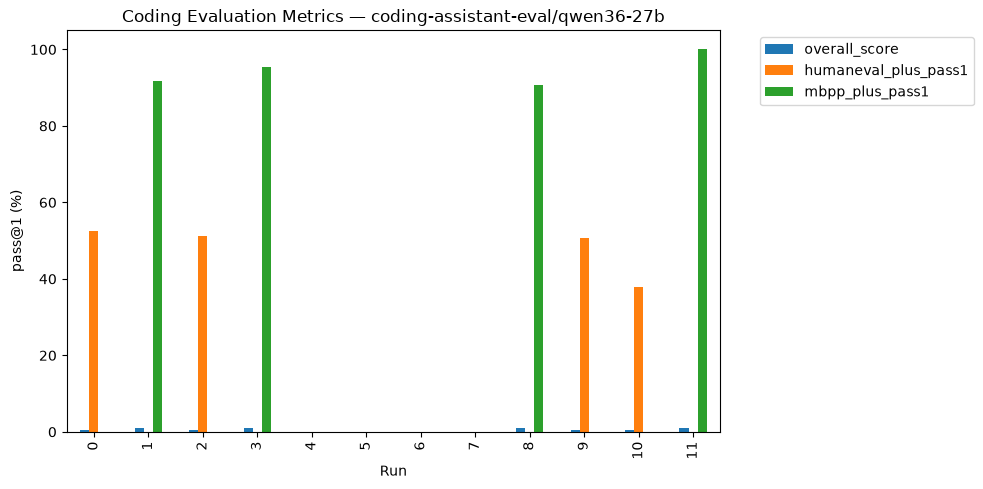

In [17]:
try:
    import matplotlib.pyplot as plt

    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if exp:
        runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
        metric_cols = [c for c in runs.columns if c.startswith('metrics.')]

        if not runs.empty and metric_cols:
            metrics_df = runs[metric_cols].dropna(axis=1, how='all')
            metrics_df.columns = [c.replace('metrics.', '') for c in metrics_df.columns]

            fig, ax = plt.subplots(figsize=(10, 5))
            metrics_df.plot(kind='bar', ax=ax)
            ax.set_title(f'Coding Evaluation Metrics — {EXPERIMENT_NAME}')
            ax.set_ylabel('pass@1 (%)')
            ax.set_xlabel('Run')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else:
            print('No metric data to visualize.')
    else:
        print(f"Experiment '{EXPERIMENT_NAME}' not found.")

except ImportError:
    print('matplotlib not installed. Install with: pip install matplotlib')
except Exception as e:
    print(f'Visualization failed: {e}')

---

## Summary

| Component | Role |
|-----------|------|
| **EvalHub** | Orchestration — schedules adapter jobs as K8s Pods, manages lifecycle |
| **Coding Eval Adapter** | Custom adapter — HumanEval+ / MBPP+ pass@1 via vLLM + mcp-code-sandbox |
| **mcp-code-sandbox** | Air-gap safe code execution for coding benchmark test suites |
| **MLflow** | Tracking — experiment with coding accuracy metrics and LLM call traces |

**Coding evaluation benchmarks:**

| Benchmark ID | Metric | Description |
|-------------|--------|-------------|
| `humaneval_plus` | pass@1 | Function completion — 164 problems with 80x test cases |
| `mbpp_plus` | pass@1 | Problem solving — 399 problems with 35x test cases |

**How it works:**
1. Adapter pod generates code completions via vLLM (chat API)
2. Generated code + test assertions are sent to mcp-code-sandbox for execution
3. Each problem has a per-task timeout — hangs are marked as failed, evaluation continues
4. pass@1 accuracy and LLM call traces are logged to MLflow

**For performance benchmarks**, see [rhoai-lmeval-builder-lab](https://github.com/hyogrin/rhoai-lmeval-builder-lab).